In [2]:
import os
from PIL import Image
from transformers import AutoImageProcessor

from videollava.model.builder import load_pretrained_model
from videollava.mm_utils import get_model_name_from_path
from videollava.eval.inference import run_inference_single

import matplotlib.pyplot as plt

In [ ]:
TEOCHAT_LOCAL = "/home/gridsan/manderson/.cache/huggingface/hub/models--jirvin16--TEOChat/snapshots/a727ec6baabcaea1bf621d226f42126eda3cc7c2"
LB_LOCAL = "/home/gridsan/manderson/.cache/huggingface/hub/models--LanguageBind--LanguageBind_Image/snapshots/d8c2e37b439f4fc47c649dc8b90cdcd3a4e0c80e"

model_name = get_model_name_from_path(TEOCHAT_LOCAL)

tokenizer, model, processor_dict, context_len = load_pretrained_model(
    model_path=TEOCHAT_LOCAL,
    model_base=None,
    model_name=model_name,
    load_8bit=True,
    load_4bit=False,
    device="cuda",
)
model = model.half()

# force local LanguageBind vision tower
vt = model.get_model().get_image_tower()
vt.image_tower_name = LB_LOCAL
vt.load_model()

# processor from same local LanguageBind path
image_processor = AutoImageProcessor.from_pretrained(
    LB_LOCAL,
    trust_remote_code=True
)

In [43]:
imagery_path = "/home/gridsan/manderson/skyscraper-s2/data/skyscraper_gdelt_sentinel/imagery/1055945148"

image_paths = sorted([
    os.path.join(imagery_path, f)
    for f in os.listdir(imagery_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

images = [Image.open(p).convert("RGB") for p in image_paths]

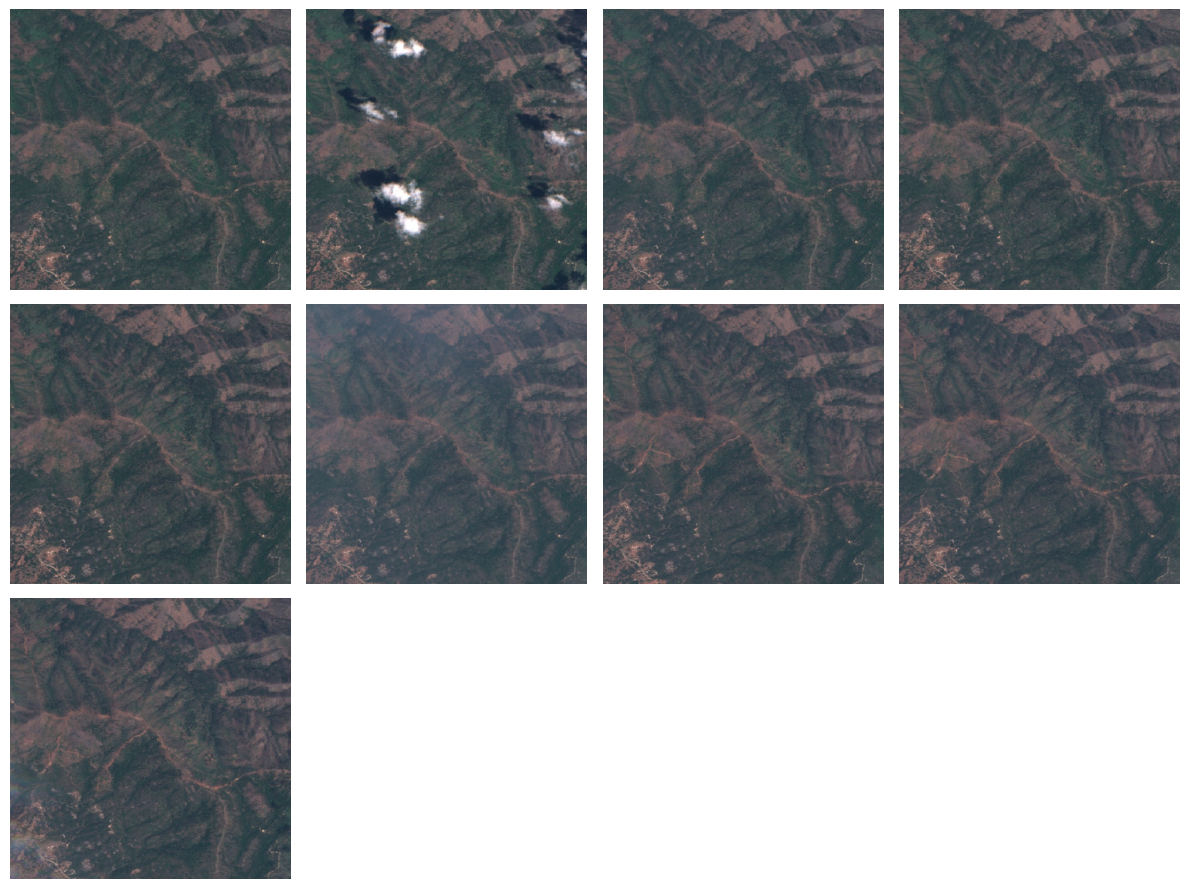

In [44]:
n = len(images)
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(12, 3 * rows))

for i, img in enumerate(images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:
prompt = "These are satellite images over time: <video>\nWhat do you see?"

model = model.to("cuda")

out = run_inference_single(
    model=model,
    processor=image_processor,
    tokenizer=tokenizer,
    inp=prompt,
    image_paths=images,   # PIL images
)

print(out)

The image shows a landscape with a road at the bottom left, and two roads at the bottom right. There are also two roads at the center of the image. The road at the bottom left is surrounded by trees, and the road at the bottom right is surrounded by trees as well. The road at the center is surrounded by trees.
